In [24]:
import os
import numpy as np
from sklearn.datasets import make_circles, make_moons, make_blobs
import subprocess
from tqdm import tqdm
import pandas as pd

### 🧪 Synthetic Toy Dataset Generator

This cell generates **2,000 synthetic toy datasets** with varying geometric structures and random parameters, useful for testing meta-learning or dataset embedding models.

---

#### **Overview of Steps**

1. **Dataset Generation (`generate_toy_dataset`)**
   - Randomly selects a dataset type: **circles**, **moons**, or **blobs**.  
   - Randomly chooses a sample size between **2¹¹ (2048)** and **2¹⁴ (16384)**.  
   - Randomizes key parameters (e.g., noise level, cluster std, circle factor).  
   - Optionally applies:
     - Random **rotation** (2D geometric transform)  
     - Random **scaling**  
     - Added **Gaussian noise**

2. **Dataset Saving**
   - Each dataset is stored in `test_datasets/` under its own folder:  
     ```
     dataset_XXXX_<type>/
     ```
   - Files inside each folder:
     - `dataset_XXXX_<type>_py.dat` → feature matrix (X)  
     - `labels_py.dat` → labels (y)
   - All files are saved as plain-text `.dat` (CSV-like) files.

---

#### **Output Summary**
- **Total datasets:** 2,000  
- **Sample size per dataset:** 2,048 – 16,384  
- **Data types:** `circles`, `moons`, `blobs`  
- **Output root:** `test_datasets/`

---

**Purpose:**  
Generate a large, diverse collection of toy datasets for benchmarking dataset representations, meta-feature extraction, or Dataset2Vec-style embeddings.


In [ ]:
import numpy as np
from sklearn.datasets import make_circles, make_moons, make_blobs
from tqdm import tqdm
import os

def generate_toy_dataset(n_features=2, random_state=None):
    rng = np.random.RandomState(random_state)

    # Step 1: Choose number of samples from 2^q where q ∈ [11, 14]
    n_samples = rng.choice([2 ** q for q in range(11, 15)])  # 2048 to 16384

    # Step 2: Choose type of dataset
    dataset_type = rng.choice(['circles', 'moons', 'blobs'])

    # Step 3: Create dataset with randomized hyperparameters
    if dataset_type == 'circles':
        factor = rng.uniform(0.3, 0.8)
        noise = rng.uniform(0.01, 0.2)
        X, y = make_circles(n_samples=n_samples, noise=noise, factor=factor, random_state=rng)

    elif dataset_type == 'moons':
        noise = rng.uniform(0.01, 0.3)
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=rng)

    elif dataset_type == 'blobs':
        n_classes = rng.randint(2, 9)
        cluster_std = rng.uniform(0.5, 3.0)
        X, y = make_blobs(n_samples=n_samples, centers=n_classes,
                          n_features=n_features, cluster_std=cluster_std, random_state=rng)

    # Step 4: Apply optional geometric transformations
    if rng.rand() < 0.5:
        # Random rotation
        angle = rng.uniform(0, 2 * np.pi)
        rotation = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        X[:, :2] = X[:, :2] @ rotation  # Only rotate first 2 dimensions

    if rng.rand() < 0.5:
        # Random scaling
        scale = rng.uniform(0.5, 2.0)
        X *= scale

    # Step 5: Add optional Gaussian noise
    if rng.rand() < 0.5:
        X += rng.normal(0, 0.1, size=X.shape)

    return X, y, dataset_type

# === SAVE DATASETS IN THE EXPECTED FORMAT ===
output_root = "test_datasets"
os.makedirs(output_root, exist_ok=True)

for i in tqdm(range(2000), desc="Generating synthetic datasets"):
    X, y, label = generate_toy_dataset(random_state=i)

    dataset_name = f"dataset_{i:04d}_{label}"
    dataset_folder = os.path.join(output_root, dataset_name)
    os.makedirs(dataset_folder, exist_ok=True)

    # Define file paths
    predictors_path = os.path.join(dataset_folder, f"{dataset_name}_py.dat")
    labels_path = os.path.join(dataset_folder, "labels_py.dat")

    # Save as plain-text CSVs (NOT binary)
    np.savetxt(predictors_path, X, delimiter=",")
    np.savetxt(labels_path, y, fmt="%d", delimiter=",")

### ⚙️ Meta-Feature Extraction from Synthetic Datasets

This cell defines and runs a helper function, **`extract_metafeatures_from_datasets()`**, which automates the extraction of meta-features for all datasets stored in the `test_datasets/` directory.

---

#### **Function Overview**

**`extract_metafeatures_from_datasets(data_root="test_datasets", extraction_script="extract_meta_features.py")`**

1. **Dataset Discovery**
   - Scans the given root folder (`data_root`) for subfolders (e.g., `dataset_0001_moons`, `dataset_0420_blobs`, etc.).
   - Each subfolder must contain:
     - `dataset_XXXX_<type>_py.dat` → predictors  
     - `labels_py.dat` → labels  

2. **Meta-Feature Extraction**
   - For each valid dataset, executes the external extraction script:  
     ```bash
     python extract_meta_features.py --file <dataset_name>
     ```
   - The script is run in a subprocess with error handling and progress tracking via `tqdm`.

3. **Error Handling**
   - Datasets missing required files are skipped.  
   - Extraction errors are caught and logged without interrupting the loop.  

4. **Return Value**
   - A summary dictionary:
     ```python
     {"extracted": <count>, "skipped": <count>}
     ```

---

#### **Usage Example**

```python
results = extract_metafeatures_from_datasets()
print(results)
# → {'extracted': 1950, 'skipped': 50}


In [ ]:
def extract_metafeatures_from_datasets(data_root="test_datasets", extraction_script="extract_meta_features.py"):
    extracted_count = 0
    skipped_count = 0

    dataset_names = [
        name for name in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, name))
    ]

    for dataset_name in tqdm(dataset_names, desc="Extracting meta-features"):
        dataset_path = os.path.join(data_root, dataset_name)
        predictors_file = os.path.join(dataset_path, f"{dataset_name}_py.dat")
        labels_file = os.path.join(dataset_path, "labels_py.dat")

        if os.path.exists(predictors_file) and os.path.exists(labels_file):
            try:
                subprocess.run(
                    ["python", extraction_script, "--file", dataset_name],
                    cwd=".", capture_output=True, text=True, check=True
                )
                extracted_count += 1
            except subprocess.CalledProcessError as e:
                print(f"❌ Error extracting {dataset_name}:\n{e.stderr}")
                skipped_count += 1
        else:
            skipped_count += 1

    return {"extracted": extracted_count, "skipped": skipped_count}

### 🧩 Combine Extracted Meta-Feature Files

This cell defines **`combine_metafeature_files()`**, which aggregates all per-dataset meta-feature CSVs into a single combined dataset for downstream analysis.

---

#### **Function Overview**

**`combine_metafeature_files(extracted_folder="extracted", output_file="synthetic_d2v/combined_metafeatures.csv", save_by_type=True)`**

1. **Input Folder Validation**
   - Checks for the existence of the `extracted/` directory, which should contain one `.csv` file per dataset (e.g., `dataset_0001_moons.csv`).
   - Creates the output directory if it does not exist.

2. **File Aggregation**
   - Iterates through all `.csv` files in `extracted_folder`.
   - Reads each file into a Pandas DataFrame, assigning its dataset ID (e.g., `dataset_0001_moons`) as the index.
   - Collects all datasets into a unified list for concatenation.

3. **Type-Based Grouping (optional)**
   - If `save_by_type=True`, datasets are grouped by their suffix type (e.g., `moons`, `circles`, `blobs`).
   - Separate combined CSVs are saved for each dataset type.

4. **Output**
   - Combines all valid meta-feature files into:
     ```
     synthetic_d2v/combined_metafeatures.csv
     ```
   - Optionally also saves:
     ```
     synthetic_d2v/combined_metafeatures_<type>.csv
     ```
   - Returns the combined Pandas DataFrame.

---

#### **Example Usage**

```python
combined_df = combine_metafeature_files()
print(combined_df.shape)


In [7]:
def combine_metafeature_files(
    extracted_folder="extracted",
    output_file="synthetic_d2v/combined_metafeatures.csv",
    save_by_type=True
):
    print("=== Combining meta-features ===")

    if not os.path.exists(extracted_folder):
        print(f"Error: '{extracted_folder}' folder not found.")
        return None

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    dfs = []
    type_to_dfs = {}

    for file in tqdm(os.listdir(extracted_folder), desc="Combining CSVs"):
        if file.endswith(".csv"):
            file_path = os.path.join(extracted_folder, file)
            dataset_id = os.path.splitext(file)[0]  # e.g., dataset_0001_moons
            try:
                df = pd.read_csv(file_path, index_col=0)
                df.index = [dataset_id]
                dfs.append(df)

                if save_by_type:
                    dataset_type = dataset_id.split("_")[-1]
                    type_to_dfs.setdefault(dataset_type, []).append(df)
            except Exception as e:
                print(f"⚠️ Error reading {file}: {e}")

    if dfs:
        combined_df = pd.concat(dfs)
        combined_df.to_csv(output_file)
        print(f"✅ Combined {len(dfs)} files into '{output_file}'")
        print(f"Final shape: {combined_df.shape}")

        if save_by_type:
            for dataset_type, df_list in type_to_dfs.items():
                type_output_file = output_file.replace(".csv", f"_{dataset_type}.csv")
                df_combined = pd.concat(df_list)
                df_combined.to_csv(type_output_file)
                print(f"📁 Saved '{dataset_type}' subset to: {type_output_file}")

        return combined_df
    else:
        print("⚠️ No valid meta-feature files found.")
        return None

### 🔍 Run Meta-Feature Extraction on All Synthetic Datasets

This cell executes the batch meta-feature extraction process using the previously defined function **`extract_metafeatures_from_datasets()`**.

---

#### **Steps Performed**

1. **Set data root**  
   Points to the folder containing all generated synthetic datasets (`test_datasets/`).

2. **Run extraction**  
   Calls the extraction routine for each dataset subfolder, invoking  
   ```bash
   python extract_meta_features.py --file <dataset_name>


In [ ]:
# Extract meta-features from all synthetic datasets
data_root = "test_datasets"
print("🔍 Starting meta-feature extraction...")
stats = extract_metafeatures_from_datasets(data_root)
print(f"✅ Extraction complete: {stats['extracted']} extracted, {stats['skipped']} skipped.")

### 🧮 Combine All Extracted Meta-Features

This cell runs the **`combine_metafeature_files()`** function to merge all individual per-dataset meta-feature CSVs into a single, unified file.

---

#### **Steps Performed**

1. **Specify input and output paths**
   - **Input folder:** `extracted/` → contains all per-dataset `.csv` files generated by the extraction step.  
   - **Output file:** `synthetic_d2v/combined_metafeatures.csv` → consolidated dataset saved here.

2. **Run combination process**
   - Reads each extracted meta-feature file.
   - Concatenates all into one large Pandas DataFrame.
   - Automatically creates the output directory if it doesn’t exist.

3. **Save results**
   - Writes a single CSV containing all datasets and their meta-features.  
   - Optionally (if `save_by_type=True`), also produces separate CSVs per dataset type (e.g., `moons`, `circles`, `blobs`).

---

#### **Example Output**



In [9]:
combined_df = combine_metafeature_files(
    extracted_folder="extracted",
    output_file="synthetic_d2v/combined_metafeatures.csv"
)

=== Combining meta-features ===


Combining CSVs: 100%|██████████| 2000/2000 [00:02<00:00, 824.03it/s] 


✅ Combined 2000 files into 'synthetic_d2v/combined_metafeatures.csv'
Final shape: (2000, 32)
📁 Saved 'blobs' subset to: synthetic_d2v/combined_metafeatures_blobs.csv
📁 Saved 'moons' subset to: synthetic_d2v/combined_metafeatures_moons.csv
📁 Saved 'circles' subset to: synthetic_d2v/combined_metafeatures_circles.csv


### 🎨 Visualize Meta-Feature Space with t-SNE

This cell performs a **t-SNE projection** of the combined meta-feature dataset to visualize how synthetic datasets of different types (`moons`, `circles`, `blobs`) are distributed in the learned feature space.

---

#### **Steps Performed**

1. **Prepare data**
   - Reset the DataFrame index and rename it to `dataset`.
   - Extract the dataset **type** (e.g., `moons`, `circles`, `blobs`) from each dataset name.
   - Split into:
     - `X` → numerical meta-features  
     - `y` → categorical dataset type labels  

2. **t-SNE projection**
   - Reduces high-dimensional meta-features to **2D space** using *t-Distributed Stochastic Neighbor Embedding* (`t-SNE`).
   - Parameters:
     - `n_components=2` → 2D visualization  
     - `n_iter=1000` → number of optimization iterations  
     - `random_state=42` → reproducible layout  

3. **Plot results**
   - Uses `matplotlib` to scatter-plot the 2D embedding.  
   - Each dataset type is shown in a different color.  
   - Includes legend and descriptive title for clarity.

---

#### **Expected Output**

A 2D scatter plot showing clusters of datasets:
- `blobs` typically form distinct, compact clusters.  
- `moons` and `circles` may overlap slightly but remain visually separable.  

📈 **Plot title:**  
`t-SNE projection of synthetic Dataset2Vec embeddings`

---

**Purpose:**  
To qualitatively inspect the separability and structure of synthetic datasets in the meta-feature space — demonstrating that datasets of similar geometric types cluster together based on their extracted representations.


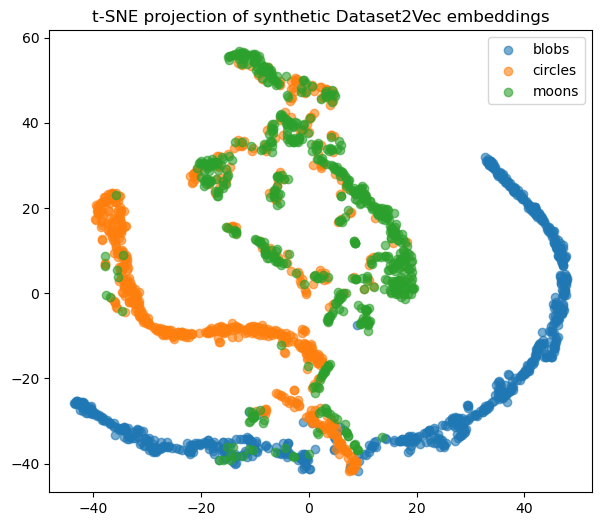

In [10]:
combined_df = combined_df.reset_index().rename(columns={"index": "dataset"})
combined_df["type"] = combined_df["dataset"].str.split("_").str[-1]
X = combined_df.drop(columns=["dataset", "type"]).values
y = combined_df["type"].values

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_embedded = TSNE(n_components=2, random_state=42, n_iter=1000).fit_transform(X)

plt.figure(figsize=(7,6))
for t in np.unique(y):
    mask = y == t
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], label=t, alpha=0.6)
plt.legend()
plt.title("t-SNE projection of synthetic Dataset2Vec embeddings")
plt.show()

### 🔁 6-Fold Cross-Validation Summary and t-SNE Visualization

This cell performs a **6-fold cross-validation split** on the combined meta-feature dataset and visualizes the test set distribution in each fold using **t-SNE projections**.

---

#### **Steps Performed**

1. **Data Preparation**
   - Extracts feature matrix `X` and target labels `y` from the combined meta-feature DataFrame.
   - Labels correspond to dataset types: **`blobs`**, **`circles`**, **`moons`**.

2. **Cross-Validation Setup**
   - Initializes a 6-fold split using `KFold` with `shuffle=True` and a fixed `random_state` for reproducibility.
   - Each fold is used to display both **Train** and **Test** distributions of dataset types.

3. **Fold Composition Summary**
   - Prints a formatted table summarizing the composition of each fold:
     ```
     Fold   Split    Total    blobs        circles      moons
     ------------------------------------------------------------
     1      Train    1666     540          555          571
            Test     334      112          111          111
     ...
     ```
   - Also reports total counts across all dataset types.

4. **t-SNE Visualization per Fold**
   - For each fold’s **test set**, applies `t-SNE` to reduce meta-features to 2D space.
   - Generates a 2×3 subplot grid (6 plots total), one for each test fold.
   - Colors points by dataset type, with legends and gridlines for clarity.

5. **Final Output**
   - A large figure showing six panels — one per fold — illustrating how the synthetic dataset embeddings are distributed across cross-validation splits.

---

#### **Expected Outcome**

- Balanced splits of `blobs`, `moons`, and `circles` across all folds.  
- Distinct clustering patterns visible in each t-SNE plot.  
- Super-title:  
  **“t-SNE projections for each test fold (6-fold CV)”**

---

**Purpose:**  
To verify that cross-validation splits maintain a balanced distribution of dataset types and to visually inspect the stability of the dataset embedding space across different test folds.



Fold Composition Summary:
----------------------------------------------------------------------
Fold   Split    Total    blobs        circles      moons       
----------------------------------------------------------------------
1      Train    1666     581          556          529         
       Test     334      120          107          107         

2      Train    1666     581          552          533         
       Test     334      120          111          103         

3      Train    1667     579          559          529         
       Test     333      122          104          107         

4      Train    1667     583          552          532         
       Test     333      118          111          104         

5      Train    1667     590          546          531         
       Test     333      111          117          105         

6      Train    1667     591          550          526         
       Test     333      110          113          110    

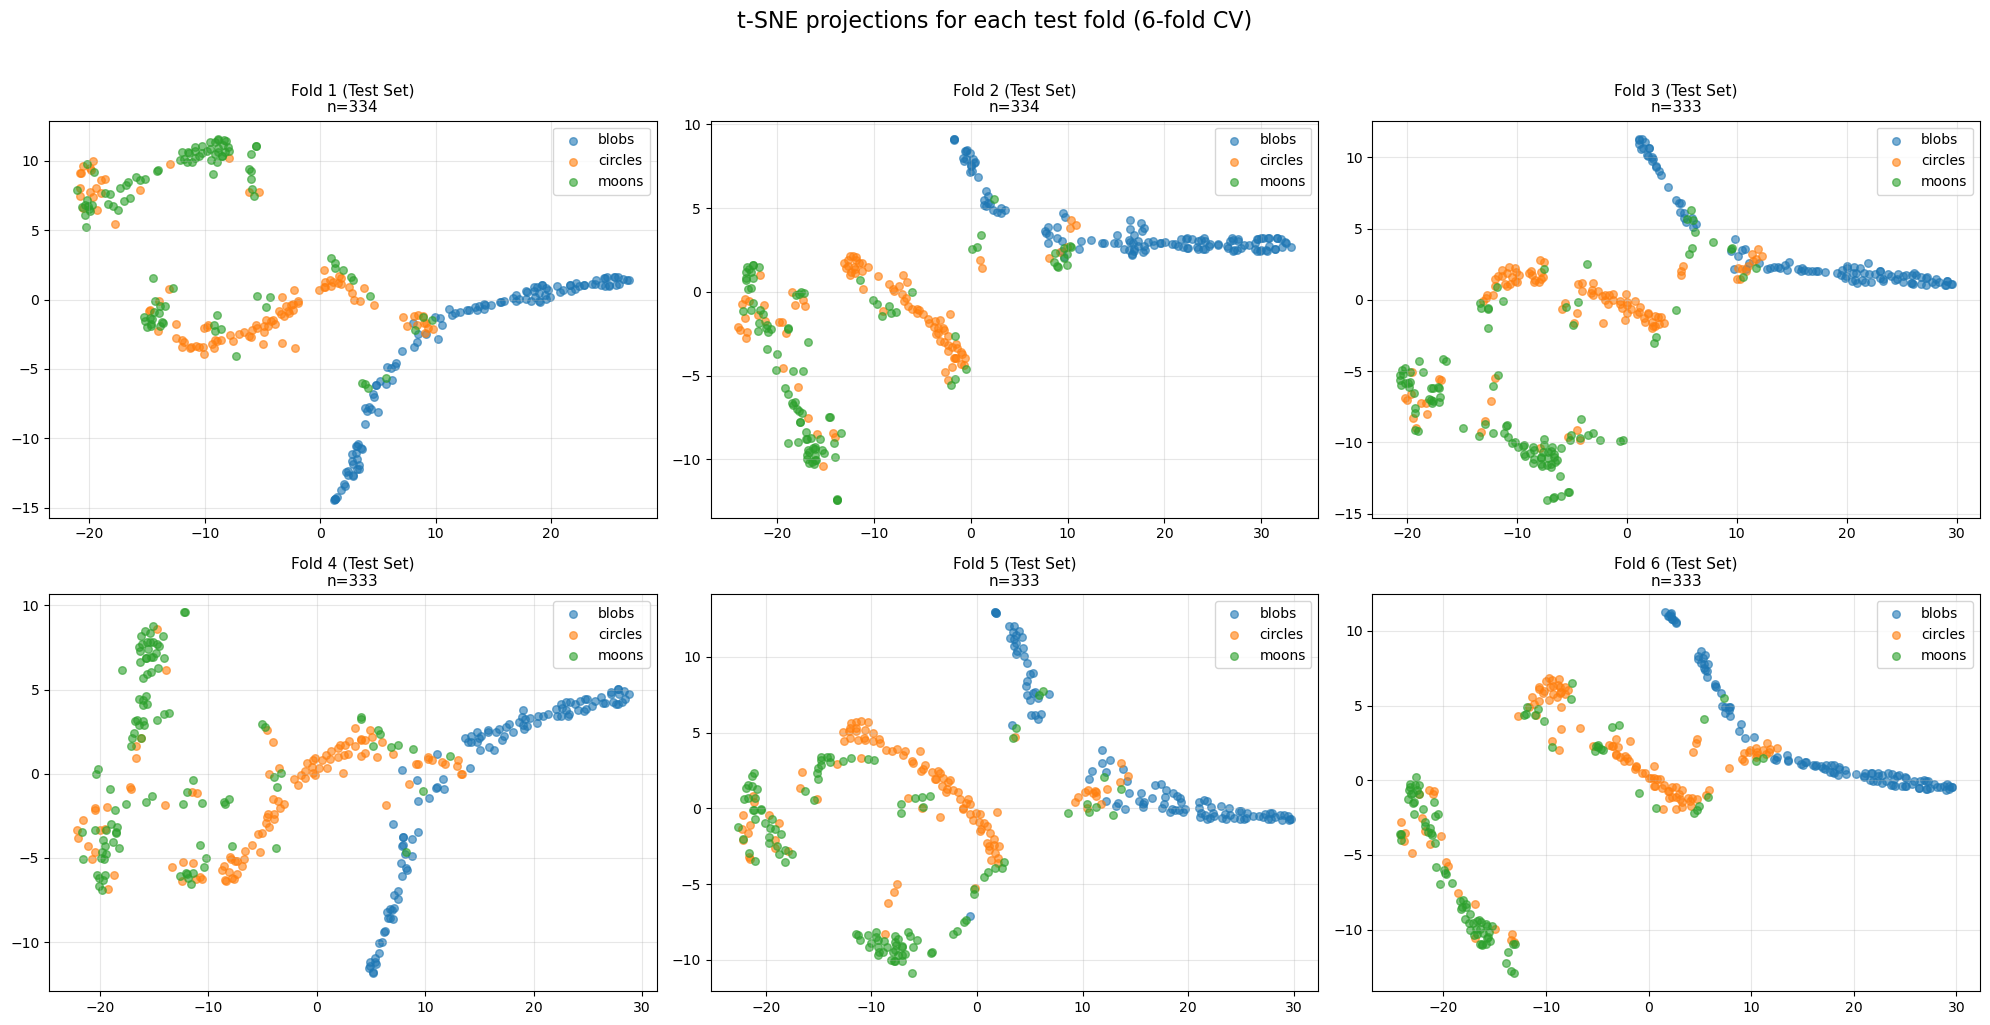

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import KFold

# Prepare data
X = combined_df.drop(columns=["dataset", "type"]).values
y = combined_df["type"].values

# === COMPACT FOLD STATISTICS ===
kf = KFold(n_splits=6, shuffle=True, random_state=10)

print("\nFold Composition Summary:")
print("-" * 70)
print(f"{'Fold':<6} {'Split':<8} {'Total':<8} {'blobs':<12} {'circles':<12} {'moons':<12}")
print("-" * 70)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    for split_name, indices in [('Train', train_idx), ('Test', test_idx)]:
        y_split = y[indices]
        unique, counts = np.unique(y_split, return_counts=True)
        count_dict = dict(zip(unique, counts))
        
        blobs = count_dict.get('blobs', 0)
        circles = count_dict.get('circles', 0)
        moons = count_dict.get('moons', 0)
        
        fold_label = f"{fold_idx + 1}" if split_name == 'Train' else ""
        print(f"{fold_label:<6} {split_name:<8} {len(indices):<8} "
              f"{blobs:<12} {circles:<12} {moons:<12}")
    print()

print("-" * 70)
print(f"{'Total':<15} {len(y):<8} "
      f"{np.sum(y == 'blobs'):<12} "
      f"{np.sum(y == 'circles'):<12} "
      f"{np.sum(y == 'moons'):<12}")
print("-" * 70)

print("\nGenerating visualizations...")

kf = KFold(n_splits=6, shuffle=True, random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows × 3 columns = 6 plots
axes = axes.flatten()  # Flatten for easy indexing

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    X_embedded = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_test)
    
    ax = axes[fold_idx]
    for t in np.unique(y_test):
        mask = y_test == t
        ax.scatter(X_embedded[mask, 0], X_embedded[mask, 1], 
                   label=t, alpha=0.6, s=30)
    
    ax.set_title(f"Fold {fold_idx + 1} (Test Set)\nn={len(test_idx)}", fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("t-SNE projections for each test fold (6-fold CV)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 📏 Intra- and Inter-Class Cosine Distance Analysis

This cell quantitatively evaluates how well the synthetic dataset embeddings separate different dataset types (`blobs`, `circles`, `moons`) in the meta-feature space by computing **cosine distances** both within and between classes.

---

#### **Steps Performed**

1. **Data Extraction**
   - Retrieves the embedding matrix `X` and corresponding class labels `y` from `combined_df`.
   - Groups dataset indices by their type using a dictionary:
     ```python
     class_indices = {'blobs': [...], 'circles': [...], 'moons': [...]}
     ```

2. **Intra-Class Distance Computation**
   - For each dataset type, computes all pairwise **cosine distances** between its embeddings.
   - Measures how tightly clustered the samples are within each class.
   - Results stored in `intra_class_dists`.

3. **Inter-Class Distance Computation**
   - For every pair of different dataset types (e.g., `blobs vs circles`), computes cosine distances across all combinations.
   - Tracks and aggregates these in `inter_class_dists`, using a progress bar (`tqdm`) for long loops.

4. **Result Summarization**
   - Prints **mean**, **standard deviation**, and **sample count** for:
     - Intra-class distances (compactness)
     - Inter-class distances (separation)
   - Example output:
     ```
     📊 Intra-class Distance Summary:
       blobs      | mean: 0.1452 | std: 0.0328 | n=...
       circles    | mean: 0.1589 | std: 0.0351 | n=...
       moons      | mean: 0.1624 | std: 0.0364 | n=...

     📊 Inter-class Distance Summary:
       blobs vs circles | mean: 0.5012 | std: 0.0827 | n=...
       blobs vs moons   | mean: 0.4885 | std: 0.0791 | n=...
       circles vs moons | mean: 0.4959 | std: 0.0803 | n=...
     ```

---

#### **Interpretation**

- **Low intra-class mean distance** → embeddings of the same type are **clustered closely** (good internal consistency).  
- **High inter-class mean distance** → embeddings of different types are **well-separated** (good discriminative power).

---

**Purpose:**  
To numerically assess the structure of the embedding space and verify that meta-feature representations capture meaningful distinctions between synthetic dataset types.


In [12]:
import numpy as np
from scipy.spatial.distance import cosine
from itertools import combinations
from tqdm import tqdm
import pandas as pd

# Extract embeddings and labels
X = combined_df.drop(columns=["dataset", "type"]).values
y = combined_df["type"].values

# Group indices by class
class_indices = {label: np.where(y == label)[0] for label in np.unique(y)}

# Compute intra-class distances
intra_class_dists = {}
for label, indices in class_indices.items():
    dists = []
    for i, j in combinations(indices, 2):
        d = cosine(X[i], X[j])
        dists.append(d)
    intra_class_dists[label] = dists

# Compute inter-class distances
inter_class_dists = []
for class1, class2 in combinations(np.unique(y), 2):
    indices1 = class_indices[class1]
    indices2 = class_indices[class2]
    for i in tqdm(indices1, desc=f"Computing inter-class: {class1} vs {class2}"):
        for j in indices2:
            d = cosine(X[i], X[j])
            inter_class_dists.append((f"{class1} vs {class2}", d))

# Summarize results
print("\n📊 Intra-class Distance Summary:")
for label, dists in intra_class_dists.items():
    print(f"  {label:<10} | mean: {np.mean(dists):.4f} | std: {np.std(dists):.4f} | n={len(dists)}")

print("\n📊 Inter-class Distance Summary:")
df_inter = pd.DataFrame(inter_class_dists, columns=["pair", "distance"])
for pair in df_inter["pair"].unique():
    subset = df_inter[df_inter["pair"] == pair]["distance"]
    print(f"  {pair:<17} | mean: {subset.mean():.4f} | std: {subset.std():.4f} | n={len(subset)}")

Computing inter-class: circles vs moons: 100%|██████████| 663/663 [00:04<00:00, 149.10it/s]



📊 Intra-class Distance Summary:
  blobs      | mean: 0.0240 | std: 0.0540 | n=245350
  circles    | mean: 0.0047 | std: 0.0068 | n=219453
  moons      | mean: 0.0036 | std: 0.0058 | n=201930

📊 Inter-class Distance Summary:
  blobs vs circles  | mean: 0.0249 | std: 0.0248 | n=464763
  blobs vs moons    | mean: 0.0291 | std: 0.0232 | n=445836
  circles vs moons  | mean: 0.0046 | std: 0.0069 | n=421668


### 🧠 Extract Meta-Features Using PyMFE

This cell defines **`extract_and_save_pymfe()`**, a flexible utility for computing meta-features from all synthetic datasets using the [PyMFE](https://pymfe.readthedocs.io/) library.

---

#### **Function Overview**

**`extract_and_save_pymfe(groups=("statistical",), data_root="test_datasets")`**

1. **Purpose**
   - Automates the extraction of **meta-feature groups** (e.g., *statistical*, *info-theory*, *model-based*, etc.) from all synthetic datasets stored in `data_root`.  
   - Saves both a **combined** meta-feature table and **type-based subsets** (e.g., `blobs`, `moons`, `circles`) for downstream analysis.

2. **Parameters**
   | Parameter | Type | Description |
   |------------|------|-------------|
   | `groups` | tuple or list of str | Names of PyMFE meta-feature groups to extract. Multiple groups can be processed sequentially. |
   | `data_root` | str | Directory containing all synthetic dataset folders (e.g., `test_datasets/`). |

3. **Processing Steps**
   - Suppresses non-critical PyMFE and NumPy warnings for cleaner output.


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
from pymfe.mfe import MFE

def extract_and_save_pymfe(groups=("statistical",), data_root="test_datasets"):
    """
    Extracts PyMFE meta-features for given group(s) from all datasets in `data_root`,
    saves a combined CSV and per-type splits under `synthetic_{group_name}` folder(s).

    Parameters
    ----------
    groups : tuple or list of str
        PyMFE meta-feature groups (e.g. ("statistical", "info-theory")).
    data_root : str
        Path to folder containing all synthetic datasets.
    """

    # --- Suppress non-critical warnings globally ---
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", module="pymfe")

    # --- Handle case where groups is a single string ---
    if isinstance(groups, str):
        groups = (groups,)

    for group in groups:
        print(f"\n=== Extracting PyMFE group: '{group}' ===")

        # Output folder and paths
        output_dir = f"synthetic_{group}"
        os.makedirs(output_dir, exist_ok=True)
        combined_path = os.path.join(output_dir, "combined_metafeatures.csv")

        # --- Collect results ---
        records = []
        dataset_names = sorted(
            name for name in os.listdir(data_root)
            if os.path.isdir(os.path.join(data_root, name))
        )

        for dataset_name in tqdm(dataset_names, desc=f"Extracting {group} features"):
            dataset_path = os.path.join(data_root, dataset_name)
            predictors_file = os.path.join(dataset_path, f"{dataset_name}_py.dat")
            labels_file = os.path.join(dataset_path, "labels_py.dat")

            if not (os.path.exists(predictors_file) and os.path.exists(labels_file)):
                continue

            try:
                # Load dataset
                X = np.loadtxt(predictors_file, delimiter=",")
                y = np.loadtxt(labels_file, delimiter=",")
                if X.ndim == 1:
                    X = X.reshape(-1, 1)

                # Remove NaN columns
                X = X[:, ~np.isnan(X).all(axis=0)]

                # Extract meta-features
                mfe = MFE(groups=(group,))
                mfe.fit(X, y)
                names, values = mfe.extract()

                record = dict(zip(names, values))
                record["dataset_name"] = dataset_name
                record["dataset_type"] = dataset_name.split("_")[-1]
                records.append(record)

            except Exception as e:
                print(f"⚠️ Skipped {dataset_name}: {e}")

        # --- Combine into DataFrame ---
        meta_df = pd.DataFrame(records).set_index("dataset_name")
        meta_df.to_csv(combined_path)
        print(f"✅ Saved combined CSV → {combined_path} ({meta_df.shape[0]} datasets, {meta_df.shape[1]} features)")

        # --- Split by dataset_type ---
        for dtype, subset in meta_df.groupby("dataset_type"):
            subset_path = os.path.join(output_dir, f"combined_metafeatures_{dtype}.csv")
            subset.to_csv(subset_path)
            print(f"📁 Saved {dtype} subset → {subset_path} ({subset.shape[0]} datasets)")


### ⚙️ Run PyMFE Extraction for the “Complexity” Feature Group

This cell calls **`extract_and_save_pymfe()`** to compute **complexity-based meta-features** for all synthetic datasets.

---

#### **Overview**

- **Selected PyMFE group:** `"complexity"`  
- **Other available groups:**  
  `['general', 'statistical', 'info-theory', 'model-based', 'landmarking', 'complexity']`

The `"complexity"` group captures structural properties of datasets — such as class overlap, boundary linearity, and feature–target relationships — providing insight into how difficult a dataset is to model.

---

#### **Steps Performed**

1. Iterates through all folders in `test_datasets/`.
2. Loads each dataset’s predictors and labels.
3. Extracts all PyMFE meta-features within the `"complexity"` group.
4. Saves:
   - A combined CSV for all datasets:  
     ```
     synthetic_complexity/combined_metafeatures.csv
     ```
   - Type-based splits:  
     ```
     synthetic_complexity/combined_metafeatures_blobs.csv
     synthetic_complexity/combined_metafeatures_circles.csv
     synthetic_complexity/combined_metafeatures_moons.csv
     ```

---

#### **Example Output**



In [ ]:
# ['general', 'statistical', 'info-theory', 'model-based', 'landmarking', 'complexity']
extract_and_save_pymfe('complexity')

In [22]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt

def evaluate_metafeatures_from_folder(folder_path, filename="combined_metafeatures.csv", random_state=42):
    """
    Loads a combined meta-feature CSV from the given folder, performs:
      1. t-SNE visualization of meta-feature embeddings
      2. Intra-class and inter-class cosine distance analysis
      3. Computes inter/intra ratio as a separability measure
      4. Saves all results (CSVs, JSON summary, t-SNE plot)
    """

    # --- 1. Construct file path (always synthetic_ prefix) ---
    synthetic_folder = f"synthetic_{folder_path}" if not folder_path.startswith("synthetic_") else folder_path
    csv_path = os.path.join(synthetic_folder, filename)

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ No file found at: {csv_path}")

    folder_path = synthetic_folder  # resolved folder

    # --- 2. Load meta-features ---
    combined_df = pd.read_csv(csv_path)

    # --- 3. Ensure columns exist ---
    if "dataset" not in combined_df.columns:
        if "dataset_name" in combined_df.columns:
            combined_df = combined_df.rename(columns={"dataset_name": "dataset"})
        else:
            combined_df = combined_df.reset_index().rename(columns={"index": "dataset"})
    if "type" not in combined_df.columns:
        combined_df["type"] = combined_df["dataset"].str.split("_").str[-1]

    # --- 4. Prepare feature matrix X and labels y ---
    X = (
        combined_df.drop(columns=["dataset", "type"])
        .select_dtypes(include=[np.number])
        .fillna(0)
        .values
    )
    y = combined_df["type"].values

    # --- 5. Run t-SNE embedding ---
    print("Running t-SNE projection...")
    X_embedded = TSNE(
        n_components=2,
        random_state=random_state,
        n_iter=1000,
        init="pca",
        learning_rate="auto"
    ).fit_transform(X)

    # --- 6. Plot ---
    plt.figure(figsize=(7, 6))
    for t in np.unique(y):
        mask = y == t
        plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], label=t, alpha=0.7, s=25)
    plt.legend(title="Dataset type")
    plt.title(f"t-SNE projection of {os.path.basename(folder_path)} meta-features")
    plt.tight_layout()
    tsne_path = os.path.join(folder_path, "tsne_projection.png")
    plt.savefig(tsne_path, dpi=300)
    plt.show()

    # --- 7. Compute cosine distances ---
    print("\nComputing cosine distances...")
    class_indices = {label: np.where(y == label)[0] for label in np.unique(y)}

    # Intra-class distances
    intra_class_dists = {}
    for label, indices in class_indices.items():
        dists = [cosine(X[i], X[j]) for i, j in combinations(indices, 2)]
        intra_class_dists[label] = dists

    # Inter-class distances
    inter_class_dists = []
    for class1, class2 in combinations(np.unique(y), 2):
        indices1, indices2 = class_indices[class1], class_indices[class2]
        for i in tqdm(indices1, desc=f"Inter-class: {class1} vs {class2}"):
            for j in indices2:
                d = cosine(X[i], X[j])
                inter_class_dists.append((f"{class1} vs {class2}", d))

    # --- 8. Summarize results ---
    intra_summary, inter_summary = [], []
    print("\n📊 Intra-class Distance Summary:")
    for label, dists in intra_class_dists.items():
        mean_val, std_val = np.mean(dists), np.std(dists)
        intra_summary.append({"type": label, "mean": mean_val, "std": std_val, "n": len(dists)})
        print(f"  {label:<10} | mean: {mean_val:.4f} | std: {std_val:.4f}")

    print("\n📊 Inter-class Distance Summary:")
    df_inter = pd.DataFrame(inter_class_dists, columns=["pair", "distance"])
    for pair in df_inter["pair"].unique():
        subset = df_inter[df_inter["pair"] == pair]["distance"]
        mean_val, std_val = subset.mean(), subset.std()
        inter_summary.append({"pair": pair, "mean": mean_val, "std": std_val, "n": len(subset)})
        print(f"  {pair:<17} | mean: {mean_val:.4f} | std: {std_val:.4f}")

    # --- 9. Compute overall ratio ---
    avg_intra = np.mean([d["mean"] for d in intra_summary])
    avg_inter = np.mean([d["mean"] for d in inter_summary])
    ratio = avg_inter / avg_intra if avg_intra > 0 else np.nan

    print("\n📈 Inter/Intra Ratio Summary:")
    print(f"  Avg intra-class distance: {avg_intra:.4f}")
    print(f"  Avg inter-class distance: {avg_inter:.4f}")
    print(f"  ➜ Inter/Intra ratio: {ratio:.2f}×")

    # --- 10. Save results ---
    intra_csv_path = os.path.join(folder_path, "intra_class_distances.csv")
    inter_csv_path = os.path.join(folder_path, "inter_class_distances.csv")
    summary_json_path = os.path.join(folder_path, "distance_summary.json")

    pd.DataFrame(intra_summary).to_csv(intra_csv_path, index=False)
    pd.DataFrame(inter_summary).to_csv(inter_csv_path, index=False)

    summary_json = {
        "intra_class": intra_summary,
        "inter_class": inter_summary,
        "tsne_plot": tsne_path,
        "summary": {
            "avg_intra": avg_intra,
            "avg_inter": avg_inter,
            "inter_intra_ratio": ratio
        }
    }
    with open(summary_json_path, "w") as f:
        json.dump(summary_json, f, indent=4)

    print(f"\n💾 Saved results to:")
    print(f"  • {intra_csv_path}")
    print(f"  • {inter_csv_path}")
    print(f"  • {summary_json_path}")
    print(f"  • {tsne_path}")
    print("\n✅ Evaluation complete.")

    return combined_df, X, y, X_embedded, ratio

### 📊 Evaluate Meta-Feature Quality Across Synthetic Datasets

This cell defines **`evaluate_metafeatures_from_folder()`**, a unified evaluation routine that loads a set of extracted meta-features (e.g., *statistical*, *complexity*, *info-theory*), performs visual and quantitative analysis, and saves all evaluation outputs.

---

#### **Function Overview**

**`evaluate_metafeatures_from_folder(folder_path, filename="combined_metafeatures.csv", random_state=42)`**

1. **Purpose**
   - To assess the **structure and separability** of synthetic dataset embeddings from a specified PyMFE group or other meta-feature source.  
   - Produces both **visual (t-SNE)** and **numerical (cosine distance)** summaries to quantify how well dataset types are represented in the feature space.

2. **Main Procedures**
   - **Load meta-feature CSV**
     - Automatically resolves folder name (e.g., `synthetic_complexity`, `synthetic_statistical`).
     - Ensures columns `dataset` and `type` exist.
   - **Prepare data**
     - Extracts numerical feature matrix `X` and corresponding dataset type labels `y`.
     - Fills missing values and ensures numeric consistency.
   - **t-SNE Visualization**
     - Projects embeddings into 2D space using *t-Distributed Stochastic Neighbor Embedding* (`t-SNE`).
     - Saves a plot to `<folder>/tsne_projection.png`.
   - **Cosine Distance Computation**
     - Computes **intra-class** (within-type) and **inter-class** (between-type) distances using cosine similarity.
     - Summarizes each with mean and standard deviation.
   - **Inter/Intra Ratio**
     - Calculates average intra- and inter-class distances, then computes their ratio as a **separability metric**:
       \[
       \text{ratio} = \frac{\text{avg(inter-class distance)}}{\text{avg(intra-class distance)}}
       \]
       - Higher ratios indicate stronger class separation in the embedding space.
   - **Save Results**
     - Saves all outputs to the evaluation folder:
       ```
       synthetic_<group>/
       ├── tsne_projection.png
       ├── intra_class_distances.csv
       ├── inter_class_distances.csv
       └── distance_summary.json
       ```

3. **Example Call**
   ```python
   evaluate_metafeatures_from_folder("synthetic_complexity")


In [23]:
# ['general', 'statistical', 'info-theory', 'model-based', 'landmarking', 'complexity']
combined_df, X, y, X_embedded, ratio = evaluate_metafeatures_from_folder("statistical")

FileNotFoundError: ❌ No file found at: synthetic_statistical/combined_metafeatures.csv

In [20]:
import matplotlib.pyplot as plt

# Reproducibly generate one of each dataset type
examples = {}
for seed in range(10000):
    X, y, dtype = generate_toy_dataset(random_state=seed)
    if dtype not in examples:
        examples[dtype] = (X, y)
    if len(examples) == 3:
        break

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (dtype, (X, y)) in zip(axes, examples.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=10, alpha=0.7, edgecolors='none')
    ax.set_title(dtype.capitalize())
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_aspect("equal")
plt.suptitle("Example Datasets: Circles, Moons, and Blobs", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'generate_toy_dataset' is not defined

In [10]:
syn_df = pd.read_csv("toys/synthetic_d2v_old/combined_metafeatures.csv",index_col = 0)
stats_df = pd.read_csv("toys/synthetic_statistical/combined_metafeatures.csv",index_col = 0)
landmarking_df = pd.read_csv("toys/synthetic_landmarking/combined_metafeatures.csv",index_col = 0)
general_df = pd.read_csv("toys/synthetic_general/combined_metafeatures.csv",index_col = 0)


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def correlation_analysis(d2v_df, pymfe_df, output_dir="correlation_stats_vs_d2v",
                         top_k=20, toys_root="toys/correlation_analysis"):
    """
    Computes Spearman correlations between D2V and PyMFE features.
    Saves:
      - Heatmap
      - Top correlated feature pairs
    Prints:
      - Top 5 positive correlations
      - Top 5 negative correlations
    """
    # ---------------------------------------------------------------------
    # 1. Construct the final output directory inside toys/correlation_analysis
    # ---------------------------------------------------------------------
    final_output_dir = os.path.join(toys_root, output_dir)
    os.makedirs(final_output_dir, exist_ok=True)

    # ---------------------------------------------------------------------
    # 2. Align datasets by index
    # ---------------------------------------------------------------------
    common = d2v_df.index.intersection(pymfe_df.index)
    d2v = d2v_df.loc[common].select_dtypes(include=[np.number]).copy()
    pymfe = pymfe_df.loc[common].select_dtypes(include=[np.number]).copy()

    # remove constant columns
    d2v = d2v.loc[:, d2v.std() > 0]
    pymfe = pymfe.loc[:, pymfe.std() > 0]

    # ---------------------------------------------------------------------
    # 3. Compute full pairwise Spearman correlations
    # ---------------------------------------------------------------------
    pairwise_corr = pd.DataFrame(index=d2v.columns, columns=pymfe.columns)

    for d_col in d2v.columns:
        for p_col in pymfe.columns:
            pairwise_corr.loc[d_col, p_col] = d2v[d_col].corr(
                pymfe[p_col], method="spearman"
            )

    pairwise_corr = pairwise_corr.astype(float)

    # ---------------------------------------------------------------------
    # 4. Save Heatmap
    # ---------------------------------------------------------------------
    plt.figure(figsize=(14, 10))
    sns.heatmap(pairwise_corr, cmap="coolwarm", center=0)
    plt.title("Spearman Correlation: D2V vs PyMFE Meta-Features")
    plt.tight_layout()
    heatmap_path = os.path.join(final_output_dir, "heatmap_spearman.png")
    plt.savefig(heatmap_path, dpi=300)
    plt.close()

    # ---------------------------------------------------------------------
    # 5. Extract top correlations and save
    # ---------------------------------------------------------------------
    melted = pairwise_corr.reset_index().melt(id_vars="index")
    melted.columns = ["D2V_feature", "PyMFE_feature", "correlation"]
    melted = melted.dropna()

    top_pos = melted.nlargest(top_k, "correlation")
    top_neg = melted.nsmallest(top_k, "correlation")

    top_pairs_path = os.path.join(final_output_dir, "top_correlated_pairs.csv")
    pd.concat([top_pos, top_neg]).to_csv(top_pairs_path, index=False)

    # ---------------------------------------------------------------------
    # 6. PRINT crucial info to output cell
    # ---------------------------------------------------------------------
    print("============================================================")
    print(f"📁 Results saved to: {final_output_dir}")
    print("============================================================\n")

    print("🔥 Top 5 POSITIVE correlations:")
    print(top_pos.head(5).to_string(index=False))
    print("\n🔥 Top 5 NEGATIVE correlations:")
    print(top_neg.head(5).to_string(index=False))

    print("\n📌 Files written:")
    print(f"  • Heatmap → {heatmap_path}")
    print(f"  • Top correlated pairs → {top_pairs_path}")
    print("============================================================")

    return pairwise_corr, top_pos, top_neg

In [18]:
pairwise_corr, top_pos, top_neg = correlation_analysis(
    d2v_df=syn_df,
    pymfe_df=general_df,
    output_dir="general_vs_d2v"
)

📁 Results saved to: toys/correlation_analysis/general_vs_d2v

🔥 Top 5 POSITIVE correlations:
D2V_feature   PyMFE_feature  correlation
         13 freq_class.mean     0.592467
         10 freq_class.mean     0.543905
         23 freq_class.mean     0.536783
          2 freq_class.mean     0.499718
          7 freq_class.mean     0.484757

🔥 Top 5 NEGATIVE correlations:
D2V_feature PyMFE_feature  correlation
         13      nr_class    -0.592467
         10      nr_class    -0.543905
         23      nr_class    -0.536783
          2      nr_class    -0.499718
          7      nr_class    -0.484757

📌 Files written:
  • Heatmap → toys/correlation_analysis/general_vs_d2v/heatmap_spearman.png
  • Top correlated pairs → toys/correlation_analysis/general_vs_d2v/top_correlated_pairs.csv


In [19]:
print(pairwise_corr)

    attr_to_inst  freq_class.mean  freq_class.sd  inst_to_attr  nr_class  \
0      -0.002409        -0.000292       0.043993      0.002409  0.000292   
1       0.000835        -0.223994       0.130965     -0.000835  0.223994   
2       0.010925         0.499718      -0.387061     -0.010925 -0.499718   
3      -0.002064         0.027643       0.025000      0.002064 -0.027643   
4      -0.000388         0.135946      -0.059169      0.000388 -0.135946   
5      -0.027952        -0.245172       0.205518      0.027952  0.245172   
6       0.020283         0.330833      -0.266835     -0.020283 -0.330833   
7       0.014349         0.484757      -0.378336     -0.014349 -0.484757   
8       0.020255         0.150346      -0.141676     -0.020255 -0.150346   
9      -0.023824        -0.250295       0.207824      0.023824  0.250295   
10      0.012002         0.543905      -0.420116     -0.012002 -0.543905   
11      0.028681         0.250719      -0.209753     -0.028681 -0.250719   
12     -0.01

In [42]:
import os
import pandas as pd

def load_and_split_meta_features(root="toys/extracted"):
    rows = []

    # ----------- Load all meta-feature CSVs -----------
    for fname in os.listdir(root):
        if fname.endswith(".csv") and fname.startswith("dataset_"):
            path = os.path.join(root, fname)
            df = pd.read_csv(path, index_col=0)

            dataset_id = fname.replace(".csv", "")
            dataset_type = dataset_id.split("_")[-1]   # circles / moons / blobs

            df["dataset"] = dataset_id
            df["dataset_type"] = dataset_type

            rows.append(df)

    # ----------- Combine into a single DataFrame -----------
    combined_df = pd.concat(rows).reset_index(drop=True)

    # ----------- Split into 3 type-specific DataFrames -----------
    df_circles = combined_df[combined_df["dataset_type"] == "circles"].reset_index(drop=True)
    df_moons   = combined_df[combined_df["dataset_type"] == "moons"].reset_index(drop=True)
    df_blobs   = combined_df[combined_df["dataset_type"] == "blobs"].reset_index(drop=True)

    return combined_df, df_circles, df_moons, df_blobs

In [43]:
combined_df, df_circles, df_moons, df_blobs = load_and_split_meta_features("toys/extracted")

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from itertools import combinations
from tqdm import tqdm

def plot_three_tsnes_d2v_with_stats(df_circles, df_moons, df_blobs, random_state=42):
    """
    Produces a 3-panel t-SNE figure using Dataset2Vec embeddings
    AND prints full intra/inter-class cosine-distance statistics.

    Pairs:
        1. circles vs blobs
        2. moons vs blobs
        3. circles vs moons
    """

    # ------------------------------------------------------------
    # Define the three pairings
    # ------------------------------------------------------------
    pairs = [
        (df_circles, df_blobs, "circles", "blobs"),
        (df_moons,   df_blobs, "moons",   "blobs"),
        (df_circles, df_moons, "circles", "moons"),
    ]

    titles = [
        "Circles vs Blobs (D2V)",
        "Moons vs Blobs (D2V)",
        "Circles vs Moons (D2V)",
    ]

    # For storing stats outputs
    all_stats = {}

    # ------------------------------------------------------------
    # Create figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ------------------------------------------------------------
    # Process each pairing
    # ------------------------------------------------------------
    for ax, (df_A, df_B, label_A, label_B), title in zip(axes, pairs, titles):

        # ---------------- Combine ----------------
        df = pd.concat([df_A, df_B]).reset_index(drop=True)

        X = df.select_dtypes(include=[np.number]).values
        y = df["dataset_type"].values

        keep = X.std(axis=0) > 0
        X = X[:, keep]

        # ---------------- t-SNE ----------------
        X_emb = TSNE(
            n_components=2,
            random_state=random_state,
            init="pca",
            learning_rate="auto",
            n_iter=1000
        ).fit_transform(X)

        # ---------------- Plot ----------------
        for lbl in [label_A, label_B]:
            mask = (y == lbl)
            ax.scatter(
                X_emb[mask, 0], X_emb[mask, 1],
                s=20, alpha=0.7, label=lbl
            )

        ax.set_title(title, fontsize=13)
        ax.set_xticks([])
        ax.set_yticks([])

        # ------------------------------------------------------------
        # DISTANCE ANALYSIS
        # ------------------------------------------------------------
        class_indices = {
            label_A: np.where(y == label_A)[0],
            label_B: np.where(y == label_B)[0]
        }

        # Intra-class distances
        intra_stats = {}
        for lbl, idxs in class_indices.items():
            d = [cosine(X[i], X[j]) for i, j in combinations(idxs, 2)]
            intra_stats[lbl] = d

        # Inter-class distances
        inter_dists = []
        for i in tqdm(class_indices[label_A], desc=f"Inter {label_A} vs {label_B}"):
            for j in class_indices[label_B]:
                inter_dists.append(cosine(X[i], X[j]))

        # Compute stats
        avg_intra = np.mean([np.mean(v) for v in intra_stats.values()])
        avg_inter = np.mean(inter_dists)
        ratio = avg_inter / avg_intra if avg_intra > 0 else np.nan

        # Print exactly in your format
        print("\n============== INTRA-CLASS DISTANCES ==============")
        for lbl, d in intra_stats.items():
            print(f"{lbl}: mean={np.mean(d):.4f}, std={np.std(d):.4f}, n={len(d)}")

        print("\n============== INTER-CLASS DISTANCES ==============")
        print(f"{label_A} vs {label_B}: mean={avg_inter:.4f}, std={np.std(inter_dists):.4f}, n={len(inter_dists)}")

        print("\n============== INTER/INTRA RATIO ==============")
        print(f"Average intra-class distance:  {avg_intra:.4f}")
        print(f"Average inter-class distance:  {avg_inter:.4f}")
        print(f"Inter / Intra ratio:          {ratio:.2f}×\n")

        # Save stats
        all_stats[f"{label_A}_vs_{label_B}"] = {
            "intra": {
                lbl: {
                    "mean": float(np.mean(d)),
                    "std": float(np.std(d)),
                    "n": len(d)
                } for lbl, d in intra_stats.items()
            },
            "inter": {
                "mean": float(avg_inter),
                "std" : float(np.std(inter_dists)),
                "n"   : len(inter_dists)
            },
            "ratio": float(ratio)
        }

    # Legend for first plot only
    axes[0].legend(loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()

    return all_stats

/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Inter circles vs blobs: 100%|██████████| 663/663 [00:01<00:00, 384.64it/s]
/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0047, std=0.0068, n=219453
blobs: mean=0.0240, std=0.0540, n=245350

============== INTER-CLASS DISTANCES ==============
circles vs blobs: mean=0.0249, std=0.0248, n=464763

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0143
Average inter-class distance:  0.0249
Inter / Intra ratio:          1.74×



Inter moons vs blobs: 100%|██████████| 636/636 [00:01<00:00, 350.14it/s]
/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



============== INTRA-CLASS DISTANCES ==============
moons: mean=0.0036, std=0.0058, n=201930
blobs: mean=0.0240, std=0.0540, n=245350

============== INTER-CLASS DISTANCES ==============
moons vs blobs: mean=0.0291, std=0.0232, n=445836

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0138
Average inter-class distance:  0.0291
Inter / Intra ratio:          2.11×



Inter circles vs moons: 100%|██████████| 663/663 [00:01<00:00, 397.30it/s]



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0047, std=0.0068, n=219453
moons: mean=0.0036, std=0.0058, n=201930

============== INTER-CLASS DISTANCES ==============
circles vs moons: mean=0.0046, std=0.0069, n=421668

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0041
Average inter-class distance:  0.0046
Inter / Intra ratio:          1.11×



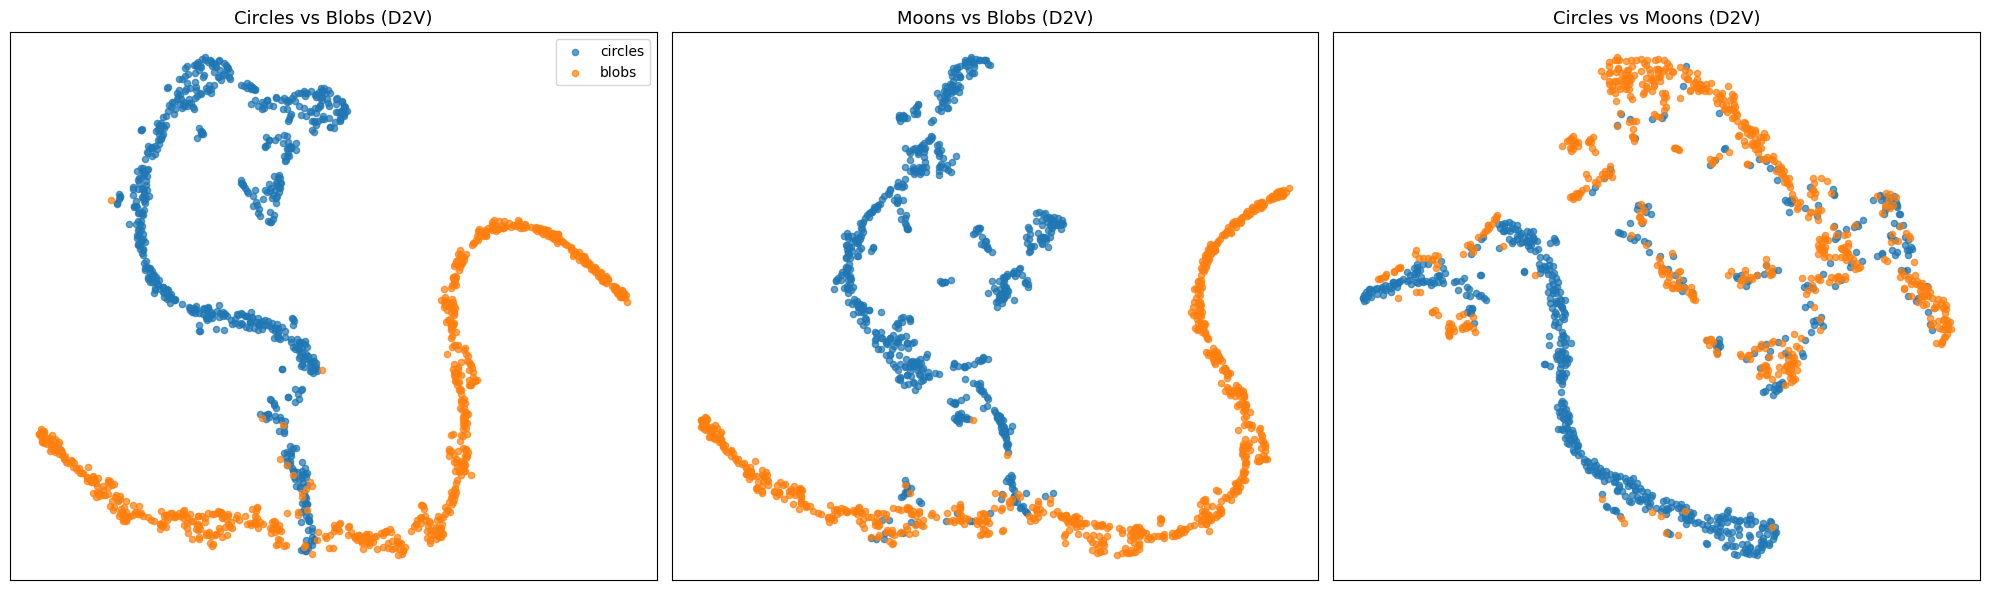

In [47]:
stats_d2v = plot_three_tsnes_d2v_with_stats(df_circles, df_moons, df_blobs)

In [49]:
import pandas as pd

root_stat = "toys/synthetic_statistical"

df_stat_circles = pd.read_csv(f"{root_stat}/combined_metafeatures_circles.csv", index_col=0)
df_stat_moons   = pd.read_csv(f"{root_stat}/combined_metafeatures_moons.csv", index_col=0)
df_stat_blobs   = pd.read_csv(f"{root_stat}/combined_metafeatures_blobs.csv", index_col=0)

df_stat_circles["dataset_type"] = "circles"
df_stat_moons["dataset_type"]   = "moons"
df_stat_blobs["dataset_type"]   = "blobs"

root_info = "toys/synthetic_info-theory"

df_info_circles = pd.read_csv(f"{root_info}/combined_metafeatures_circles.csv", index_col=0)
df_info_moons   = pd.read_csv(f"{root_info}/combined_metafeatures_moons.csv", index_col=0)
df_info_blobs   = pd.read_csv(f"{root_info}/combined_metafeatures_blobs.csv", index_col=0)

df_info_circles["dataset_type"] = "circles"
df_info_moons["dataset_type"]   = "moons"
df_info_blobs["dataset_type"]   = "blobs"

/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Inter circles vs blobs: 100%|██████████| 663/663 [00:01<00:00, 364.60it/s]



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0333, std=0.0419, n=219453
blobs: mean=0.2124, std=0.1735, n=245350

============== INTER-CLASS DISTANCES ==============
circles vs blobs: mean=0.5282, std=0.1730, n=464763

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.1229
Average inter-class distance:  0.5282
Inter / Intra ratio:          4.30×



/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Inter moons vs blobs: 100%|██████████| 636/636 [00:01<00:00, 390.61it/s]
/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



============== INTRA-CLASS DISTANCES ==============
moons: mean=0.0639, std=0.0424, n=201930
blobs: mean=0.2124, std=0.1735, n=245350

============== INTER-CLASS DISTANCES ==============
moons vs blobs: mean=0.3487, std=0.1181, n=445836

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.1382
Average inter-class distance:  0.3487
Inter / Intra ratio:          2.52×



Inter circles vs moons: 100%|██████████| 663/663 [00:01<00:00, 414.50it/s]



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0323, std=0.0433, n=219453
moons: mean=0.0645, std=0.0426, n=201930

============== INTER-CLASS DISTANCES ==============
circles vs moons: mean=0.2347, std=0.0699, n=421668

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0484
Average inter-class distance:  0.2347
Inter / Intra ratio:          4.85×



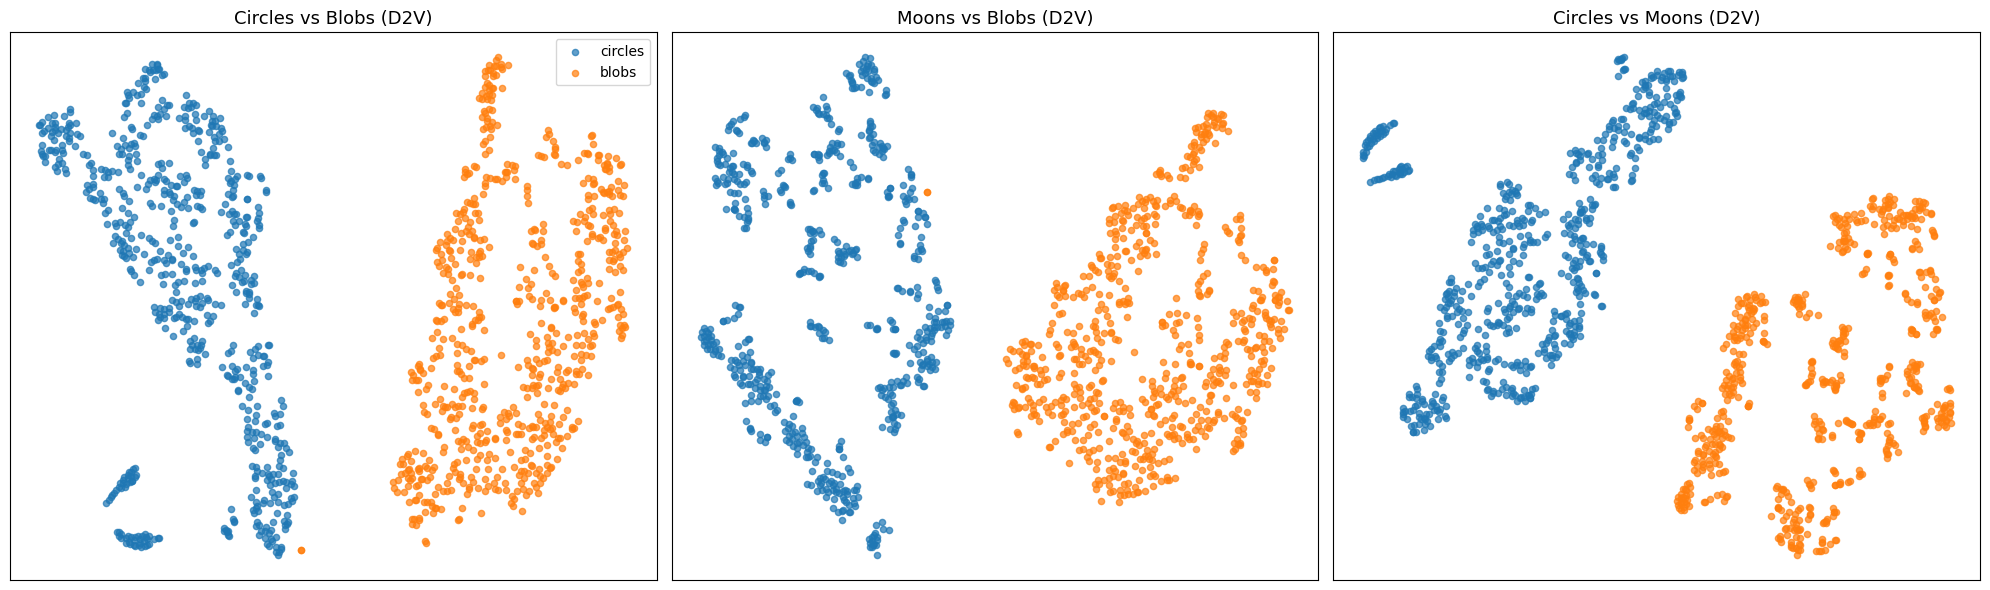

In [50]:
stats_stat = plot_three_tsnes_d2v_with_stats(df_stat_circles, df_stat_moons, df_stat_blobs)

/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Inter circles vs blobs: 100%|██████████| 663/663 [00:02<00:00, 310.21it/s]
/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0261, std=0.0313, n=219453
blobs: mean=0.0581, std=0.0884, n=245350

============== INTER-CLASS DISTANCES ==============
circles vs blobs: mean=0.3103, std=0.1612, n=464763

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0421
Average inter-class distance:  0.3103
Inter / Intra ratio:          7.36×



Inter moons vs blobs: 100%|██████████| 636/636 [00:01<00:00, 389.53it/s]
/Users/anukhayri/miniconda3/envs/keras2/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



============== INTRA-CLASS DISTANCES ==============
moons: mean=0.0089, std=0.0109, n=201930
blobs: mean=0.0581, std=0.0884, n=245350

============== INTER-CLASS DISTANCES ==============
moons vs blobs: mean=0.1686, std=0.0970, n=445836

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0335
Average inter-class distance:  0.1686
Inter / Intra ratio:          5.03×



Inter circles vs moons: 100%|██████████| 663/663 [00:01<00:00, 451.23it/s]



============== INTRA-CLASS DISTANCES ==============
circles: mean=0.0256, std=0.0308, n=219453
moons: mean=0.0087, std=0.0107, n=201930

============== INTER-CLASS DISTANCES ==============
circles vs moons: mean=0.0466, std=0.0473, n=421668

============== INTER/INTRA RATIO ==============
Average intra-class distance:  0.0172
Average inter-class distance:  0.0466
Inter / Intra ratio:          2.71×



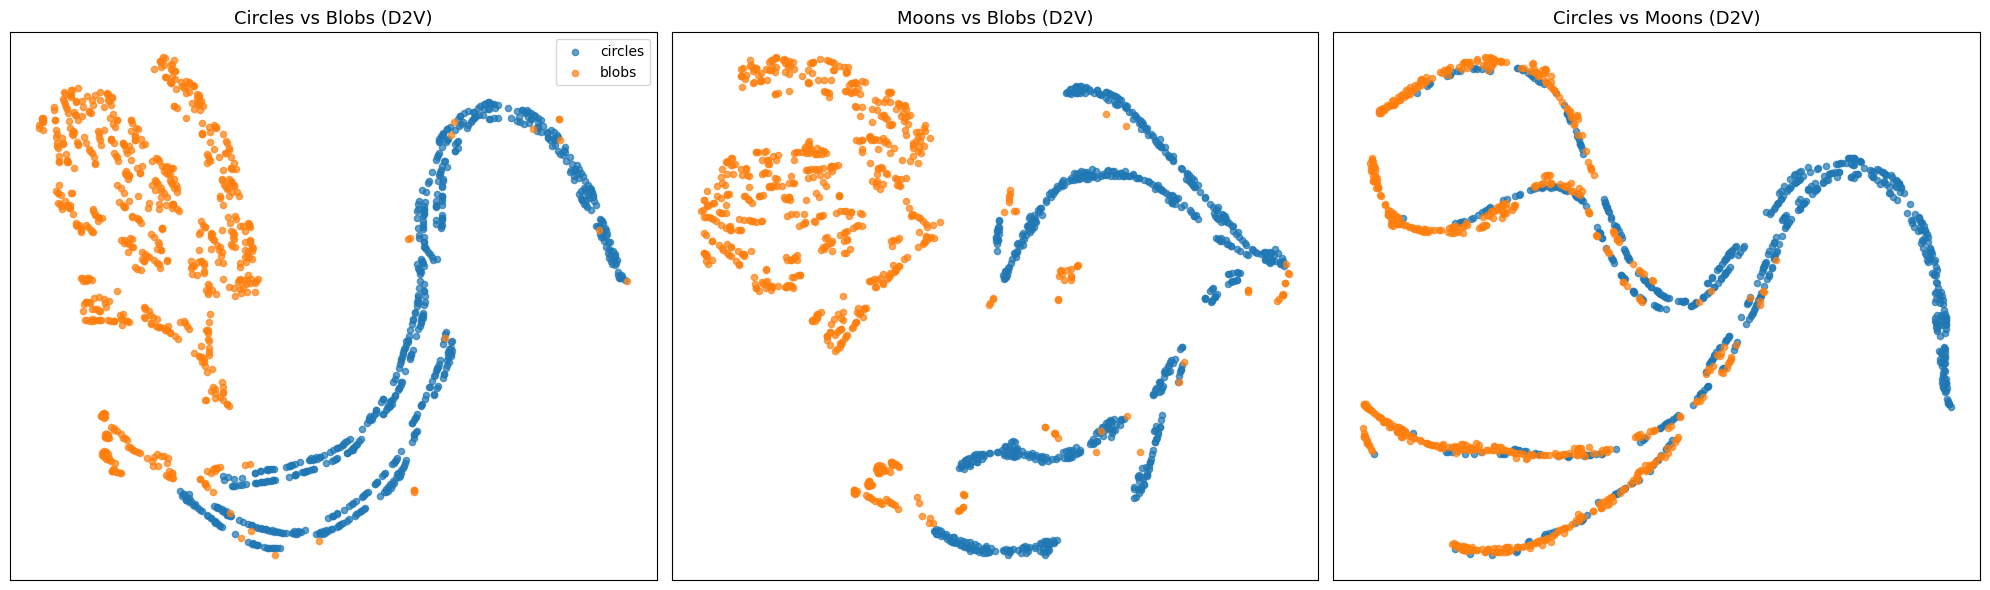

In [51]:
stats_info = plot_three_tsnes_d2v_with_stats(df_info_circles, df_info_moons, df_info_blobs)